# One-hidden-layer neural network with PyTorch

Reproduce the $2\rightarrow2\rightarrow1$ XOR network from the previous notebook using PyTorch, then compare its forward pass, loss, gradients, and training with the manual NumPy implementation.

$$
\mathbf Z_1=\mathbf X\mathbf W_1^{\mathsf T}+\mathbf b_1,\qquad
\mathbf A_1=\tanh(\mathbf Z_1),\qquad
\mathbf Z_2=\mathbf A_1\mathbf W_2^{\mathsf T}+b_2,\qquad
\hat{\mathbf y}=\sigma(\mathbf Z_2).
$$

PyTorch's `nn.Linear` stores its weight matrix with shape `(out_features, in_features)`, which is why the transposes appear above. We will use CPU tensors with `torch.float64` so that comparisons with NumPy are as direct as possible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.optim as optim

## XOR training data

The target is $y=x_1\oplus x_2$: it equals $1$ when the two binary inputs differ and $0$ when they are equal.

In [2]:
X = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]], dtype=torch.float64, requires_grad=False, device='cpu')
y = torch.tensor([[0.0], [1.0], [1.0], [0.0]], dtype=torch.float64, requires_grad=False)

## Define the network

The model contains a linear map from two inputs to two hidden neurons, a $\tanh$ activation applied elementwise, and a linear map from the hidden layer to one output logit:

$$
\mathbb R^2 \xrightarrow{\mathrm{Linear}(2,2)} \mathbb R^2
\xrightarrow{\tanh} \mathbb R^2
\xrightarrow{\mathrm{Linear}(2,1)} \mathbb R.
$$

The model itself will not include a final sigmoid because the loss function will combine the sigmoid and binary cross-entropy operations numerically stably.

In [3]:
torch.manual_seed(42)

model = nn.Sequential(
    nn.Linear(2, 2, dtype=torch.float64),
    nn.Tanh(),
    nn.Linear(2, 1, dtype=torch.float64)
)

display(model)

Sequential(
  (0): Linear(in_features=2, out_features=2, bias=True)
  (1): Tanh()
  (2): Linear(in_features=2, out_features=1, bias=True)
)

## Forward pass

PyTorch sends the entire batch through each layer in sequence. The model returns the output logits $\mathbf Z_2$; probabilities are obtained separately with

$$
\hat{\mathbf y}=\sigma(\mathbf Z_2)=\frac{1}{1+e^{-\mathbf Z_2}},
$$

where the sigmoid is applied elementwise.

In [4]:
logits = model(X)
probabilities = torch.sigmoid(logits)

In [5]:
display(logits)
print("")

display(probabilities)
print("")

tensor([[-0.5850],
        [-1.2789],
        [-1.2394],
        [-1.6319]], dtype=torch.float64, grad_fn=<AddmmBackward0>)

tensor([[0.3578],
        [0.2177],
        [0.2245],
        [0.1636]], dtype=torch.float64, grad_fn=<SigmoidBackward0>)

## Binary cross-entropy loss

For a batch of $N$ examples, the mean binary cross-entropy is

$$
J=-\frac{1}{N}\sum_{i=1}^{N}
\left[y_i\log\sigma(z_i)+(1-y_i)\log\left(1-\sigma(z_i)\right)\right].
$$

`BCEWithLogitsLoss` evaluates this directly from the logits $z_i$. Therefore, pass it `logits` and `y`—not the already-sigmoided probabilities.

In [6]:
loss_function = nn.BCEWithLogitsLoss()

loss = loss_function(logits, y)

display(loss)

tensor(0.9099, dtype=torch.float64,
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

## Automatic differentiation

Calling `loss.backward()` applies the chain rule through both linear layers and the $\tanh$ activation. At the output, PyTorch begins with

$$
d\mathbf Z_2=\frac{1}{N}(\hat{\mathbf y}-\mathbf y),
$$

then computes the gradients of the loss with respect to every trainable weight and bias. These values are accumulated in each parameter's `.grad` attribute.

In [7]:
model.zero_grad()

loss.backward()

In [8]:
for name, param in model.named_parameters():
    print(f"Name:  {name}")
    print(f"Shape: {param.shape}")
    print(f"Grad:\n{param.grad}\n")

Name:  0.weight
Shape: torch.Size([2, 2])
Grad:
tensor([[-0.0820, -0.0835],
        [-0.0792, -0.0708]], dtype=torch.float64)

Name:  0.bias
Shape: torch.Size([2])
Grad:
tensor([-0.1159, -0.1034], dtype=torch.float64)

Name:  2.weight
Shape: torch.Size([1, 2])
Grad:
tensor([[0.1739, 0.1761]], dtype=torch.float64)

Name:  2.bias
Shape: torch.Size([1])
Grad:
tensor([-0.2591], dtype=torch.float64)



## One gradient-descent update

`torch.optim.SGD` updates every trainable parameter $\theta$ using

$$
\theta\leftarrow\theta-\eta\frac{\partial J}{\partial\theta},
$$

where $\eta$ is the learning rate. For direct comparison with the manual implementation, use $\eta=0.1$.

In [9]:
optimizer = optim.SGD(model.parameters(), lr=0.1)
optimizer.step()

logits_updated = model(X)
loss_updated = loss_function(logits_updated, y)

display(loss_updated)

tensor(0.8925, dtype=torch.float64,
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

## Train the network

Each epoch performs the same five operations:

1. clear the accumulated gradients;
2. compute the logits;
3. compute the loss;
4. backpropagate the gradients;
5. update the parameters.

Because all four XOR examples are used in every epoch, this is full-batch gradient descent, even though the PyTorch optimizer class is named `SGD`.

In [10]:
loss_history = []
epochs = 10_000

for epoch in range(epochs):
    optimizer.zero_grad()
    logits = model(X)

    loss = loss_function(logits, y)
    loss_history.append(loss.item())

    loss.backward()
    optimizer.step()

display(loss_history[0])
print("")

display(loss_history[-1])
print("")

0.89251974584889

0.003769111634793146

## Evaluate the trained classifier

Convert the trained logits into probabilities and classify each example with a threshold of $0.5$:

$$
\hat y_{\mathrm{class}}=
\begin{cases}
1, & \sigma(z)\geq0.5,\\
0, & \sigma(z)<0.5.
\end{cases}
$$

Evaluation does not require a computation graph, so perform it inside a `torch.no_grad()` context.

In [11]:
model.eval()

with torch.no_grad():
    final_logits = model(X)
    final_probabilities = torch.sigmoid(final_logits)
    display(final_probabilities)
    print("")

    predictions = torch.where(final_probabilities >= 0.5, 1, 0)
    display(predictions)
    print("")

    display(y)
    print("")

    correct = predictions == y
    accuracy = correct.to(torch.float64).mean()
    print(f"Accuracy: {accuracy.item():.0%}")
    

tensor([[0.0048],
        [0.9974],
        [0.9974],
        [0.0050]], dtype=torch.float64)

tensor([[0],
        [1],
        [1],
        [0]])

tensor([[0.],
        [1.],
        [1.],
        [0.]], dtype=torch.float64)


Accuracy: 100%


## Training loss

The logarithmic vertical scale makes the loss reduction across the full training run visible.

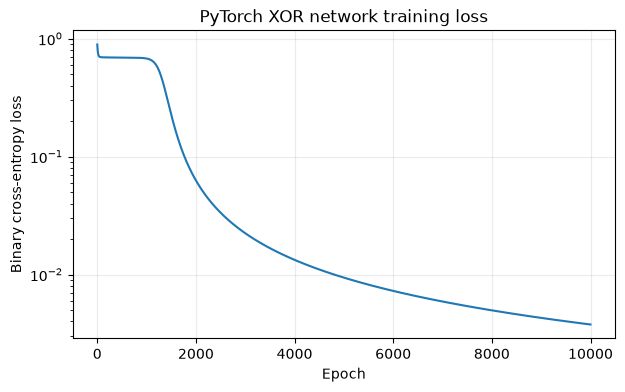

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(loss_history)
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary cross-entropy loss")
ax.set_title("PyTorch XOR network training loss")
ax.set_yscale("log")
ax.grid(alpha=0.25)
plt.show()

## Learned XOR probability surface

The colour represents the model's predicted probability. The black contour is the $0.5$ classification boundary. Unlike a single sigmoid neuron, the hidden-layer network can form the nonlinear regions required by XOR.

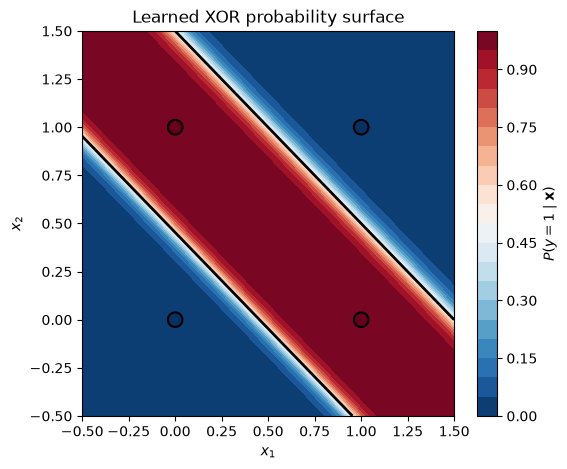

In [13]:
x1_values = np.linspace(-0.5, 1.5, 300)
x2_values = np.linspace(-0.5, 1.5, 300)
grid_x1, grid_x2 = np.meshgrid(x1_values, x2_values)
grid = np.column_stack((grid_x1.ravel(), grid_x2.ravel()))
grid_tensor = torch.tensor(grid, dtype=X.dtype, device=X.device)

with torch.no_grad():
    grid_probabilities = torch.sigmoid(model(grid_tensor))

probability_surface = grid_probabilities.cpu().numpy().reshape(grid_x1.shape)

fig, ax = plt.subplots(figsize=(6, 5))
filled = ax.contourf(
    grid_x1, grid_x2, probability_surface,
    levels=np.linspace(0.0, 1.0, 21), cmap="RdBu_r", vmin=0.0, vmax=1.0
)
ax.contour(grid_x1, grid_x2, probability_surface, levels=[0.5], colors="black", linewidths=2)
ax.scatter(
    X[:, 0].cpu().numpy(), X[:, 1].cpu().numpy(),
    c=y.squeeze().cpu().numpy(), cmap="RdBu_r", vmin=0.0, vmax=1.0,
    s=110, edgecolors="black", linewidths=1.5
)
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_title("Learned XOR probability surface")
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
fig.colorbar(filled, ax=ax, label=r"$P(y=1\mid\mathbf{x})$")
plt.show()

## Conclusion

This notebook reproduced the $2\rightarrow2\rightarrow1$ XOR network with PyTorch. `nn.Linear` represented the trainable affine transformations, `nn.Tanh` supplied the nonlinear hidden representation, autograd calculated the gradients through both layers, and `torch.optim.SGD` updated every parameter.

The crucial difference from the single sigmoid neuron is the hidden nonlinearity: two hidden neurons can combine multiple linear boundaries and represent XOR. Random initialization is required to break symmetry between those neurons; initializing the entire network to zero would leave it unable to learn.